In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Split features and labels
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

In [18]:
# Scale pixel values (0–255 → 0–1) Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
# Convert to 28x28 images with 1 channel (Reshape for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Convolution + pooling
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

# Flatten + Dense
model.add(Flatten())
model.add(Dense(64, activation='relu'))

model.add(Dropout(0.2))

# Output layer (10 classes)
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7553 - loss: 0.6943 - val_accuracy: 0.8454 - val_loss: nan
Epoch 2/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8477 - loss: 0.4239 - val_accuracy: 0.8623 - val_loss: nan
Epoch 3/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8732 - loss: 0.3519 - val_accuracy: 0.8725 - val_loss: nan
Epoch 4/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8898 - loss: 0.3096 - val_accuracy: 0.8682 - val_loss: nan
Epoch 5/5
333/333 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9009 - loss: 0.2751 - val_accuracy: 0.8733 - val_loss: nan


In [22]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8696 - loss: 0.3568
Test Accuracy: 0.8695999979972839
Test Loss: 0.3568364381790161


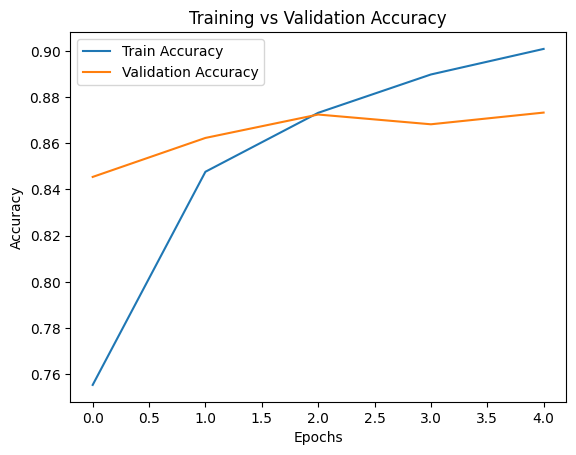

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


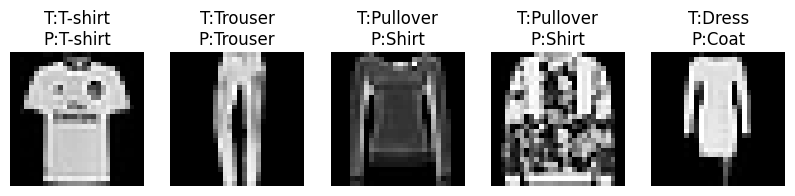

In [24]:
# Sample Predictions
labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred = np.argmax(model.predict(X_test), axis=1)

plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"T:{labels[y_test[i]]}\nP:{labels[y_pred[i]]}")
    plt.axis('off')
plt.show()

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1000
           1       0.98      0.97      0.98      1000
           2       0.94      0.59      0.72      1000
           3       0.93      0.84      0.88      1000
           4       0.68      0.93      0.79      1000
           5       0.95      0.97      0.96      1000
           6       0.64      0.72      0.68      1000
           7       0.94      0.94      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
print(cm)

[[825   2   2  20   6   2 134   0   9   0]
 [  1 971   3  13   5   1   6   0   0   0]
 [ 13   1 586   7 228   0 162   0   3   0]
 [ 28   8   3 843  87   0  31   0   0   0]
 [  0   0   9   8 933   0  49   0   1   0]
 [  0   1   0   0   0 974   0  13   2  10]
 [124   2  19  18 112   0 717   0   8   0]
 [  0   0   0   0   0  30   0 938   0  32]
 [  2   2   2   0   4  12  15   3 959   1]
 [  0   0   0   0   1   7   0  42   0 950]]


<Figure size 600x500 with 0 Axes>